How do the $^{222}Rn$ measurements in Canfranc correlate with the fiducial background rate we detect within the NEXT-100 fiducial volume?

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis')

from libs import crudo
from libs import fit_functions as ff
from libs import plotting_tools as pt

from datetime import datetime
from iminuit import Minuit
from iminuit.cost import LeastSquares
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from PIL import Image
import scipy

# Styling Plot
pt.ccortesp_plot_style()
PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Preliminary

In [2]:
# ----- Configuration ----- #
DATA_PERIOD = 1                 # Options: 1, 2
DETECTOR_CONDITION = 'castle_pclosed'       # Options: None, 'castle_open', 'castle_closed', 'castle_closed_RAS', 'castle_pclosed', 'castle_pclosed_RAS'
VERSION_TAG = 'rescale_p1'      # Options: 'rescale_p1', 'p2'

# ----- Detector Conditions Dates ----- #
# Period 01
CPC_RAS = 1746791100      # Castle = partially closed & RAS = on
CPC     = 1747042200      # Castle = partially closed & RAS = off
CC_RAS  = 1749024786      # Castle = closed & RAS = on
# Period 02
CC_02      = 1753092000   # Castle = closed & RAS = off
CC_RAS_02  = 1754035200   # Castle = closed & RAS = on

# ----- Special Dates ----- #
SEP_2025 = 1756764000     # 2nd September 2025

# ----- Scaling Factors ----- #
RESCALE_FACTOR_PERIOD_1 = 0.8851    # From Rescaling_p1_Analysis.ipynb
FIDUCIAL_EFF_STD = 8e-3             # Standard fiducial efficiency for correction. From Plotting_Rates_Effs.ipynb

# ----- LSC Reports ----- #
LSC_DIR  = "/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/lsc/"

if DATA_PERIOD == 1 and DETECTOR_CONDITION == 'castle_pclosed':
    LSC_FILENAMES = ['radon_HALLA_05052025_12052025.txt', 'radon_HALLA_12052025_19052025.txt','radon_HALLA_19052025_27052025.txt', 'radon_HALLA_27052025_02062025.txt']

elif DATA_PERIOD == 2 and DETECTOR_CONDITION == 'castle_closed':
    LSC_FILENAMES = ['radon_HALLA_21072025_28072025.txt', 'radon_HALLA_28072025_04082025.txt']
    
elif DATA_PERIOD == 2 and DETECTOR_CONDITION == 'castle_closed_RAS':
    LSC_FILENAMES = ['radon_HALLA_04082025_11082025.txt', 'radon_HALLA_11082025_18082025.txt', 'radon_HALLA_18082025_25082025.txt', 'radon_HALLA_25082025_01092025.txt']

### Load Runs & Summary Information

In [3]:
# ----- Main Directories ----- #
RUNS_INFO_DIR = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/utilities/'
SUMMARY_DIR   = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/summaries/'

# ----- Filenames ----- #
SUMMARY_FILENAME = f'summary_{VERSION_TAG}_updated.csv'

# ----- Load Dataframes ----- #
RUNS_INFO_DF = pd.read_csv(os.path.join(RUNS_INFO_DIR, f'runs_information.csv'))
RUNS_INFO_DF.columns = RUNS_INFO_DF.columns.str.strip()

SUMMARY_DF = pd.read_csv(os.path.join(SUMMARY_DIR, SUMMARY_FILENAME))
SUMMARY_DF.drop(columns=['Unnamed: 0'], inplace=True)
SUMMARY_DF.columns = SUMMARY_DF.columns.str.strip()
SUMMARY_DF.sort_values(by='Run_ID', inplace=True)

### Construct Rates Dataframe

In [4]:
selection_mask = pd.Series(True, index=RUNS_INFO_DF.index)

runs_in_summary = SUMMARY_DF['Run_ID'].unique()
print(f"→ Must be one of the {len(runs_in_summary)} runs in the summary")
selection_mask &= RUNS_INFO_DF['run_number'].isin(runs_in_summary)

if DATA_PERIOD is not None:
    print(f"→ Period == {DATA_PERIOD}")
    # The '&=' operator is a shortcut for 'selection_mask = selection_mask & ...'
    selection_mask &= (RUNS_INFO_DF['period'] == DATA_PERIOD)

if DETECTOR_CONDITION is not None:
    print(f"→ Condition == '{DETECTOR_CONDITION}'")
    selection_mask &= (RUNS_INFO_DF['condition'] == DETECTOR_CONDITION)

RUNS_TO_ANALYZE = RUNS_INFO_DF.loc[selection_mask, 'run_number'].values
print(f"\nSelected {len(RUNS_TO_ANALYZE)} runs for analysis:\n{RUNS_TO_ANALYZE}")

→ Must be one of the 45 runs in the summary
→ Period == 1
→ Condition == 'castle_pclosed'

Selected 16 runs for analysis:
[15299 15318 15319 15330 15331 15332 15462 15472 15478 15479 15484 15485
 15486 15487 15488 15489]


In [5]:
rates_info_columns = ['Run_ID', 'Duration', 'Date_CV', 'Date_Err', 'OK', 'LOST', 'Reconstructed', 'nElectron_Fiducial']
RATES_DF = SUMMARY_DF.loc[SUMMARY_DF['Run_ID'].isin(RUNS_TO_ANALYZE), rates_info_columns]
RATES_DF.sort_values(by='Run_ID', inplace=True)
RATES_DF

,Run_ID,Duration,Date_CV,Date_Err,OK,LOST,Reconstructed,nElectron_Fiducial
0,15299,60204,1.747095e+09,146.9611,18014,8929,17411,204.0
1,15318,86706,1.747194e+09,172.3596,28735,10115,28043,338.0
2,15319,85823,1.747281e+09,174.1556,27973,10086,27274,305.0
3,15330,86462,1.747704e+09,171.3388,28157,10432,27508,302.0
4,15331,85389,1.747791e+09,172.0570,27390,9966,26800,293.0
5,15332,67758,1.747868e+09,154.4476,22010,8142,21445,235.0
6,15462,39365,1.747948e+09,115.9820,12847,4532,12533,108.0
7,15472,86563,1.748048e+09,175.7367,28505,10015,27372,300.0
8,15478,86835,1.748210e+09,174.0899,28702,9999,27808,322.0
9,15479,86876,1.748297e+09,174.5319,28713,10036,27966,343.0


There may be some exclusions, if so apply them here

In [6]:
# Exclusion criterias
excluded_runs  = {15462, 15625, 15626, 15627}
date_threshold = SEP_2025   # For Rn paper

# Masks
exclusion_mask = ~RATES_DF['Run_ID'].isin(excluded_runs)
date_mask      = RATES_DF['Date_CV'] <= date_threshold

# ----- Final Dataframe ----- #
RATES_DF = RATES_DF.loc[exclusion_mask & date_mask].copy()
RATES_DF

,Run_ID,Duration,Date_CV,Date_Err,OK,LOST,Reconstructed,nElectron_Fiducial
0,15299,60204,1.747095e+09,146.9611,18014,8929,17411,204.0
1,15318,86706,1.747194e+09,172.3596,28735,10115,28043,338.0
2,15319,85823,1.747281e+09,174.1556,27973,10086,27274,305.0
3,15330,86462,1.747704e+09,171.3388,28157,10432,27508,302.0
4,15331,85389,1.747791e+09,172.0570,27390,9966,26800,293.0
5,15332,67758,1.747868e+09,154.4476,22010,8142,21445,235.0
7,15472,86563,1.748048e+09,175.7367,28505,10015,27372,300.0
8,15478,86835,1.748210e+09,174.0899,28702,9999,27808,322.0
9,15479,86876,1.748297e+09,174.5319,28713,10036,27966,343.0
10,15484,86538,1.748397e+09,172.9619,28188,10465,27361,312.0


### Dictionaries Definition

In [7]:
# Store here the fiducial rate for each run
FIDUCIAL_INFO = {
                    run_id: {"start": 0, "end": 0, "rate_CV": 0, "rate_Err": 0} 
                    for run_id in RATES_DF['Run_ID'].unique()
                }
FIDUCIAL_INFO

{15299: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Err': 0},
 15318: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Err': 0},
 15319: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Err': 0},
 15330: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Err': 0},
 15331: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Err': 0},
 15332: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Err': 0},
 15472: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Err': 0},
 15478: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Err': 0},
 15479: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Err': 0},
 15484: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Err': 0},
 15485: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Err': 0},
 15486: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Err': 0},
 15487: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Err': 0},
 15488: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Err': 0},
 15489: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Err': 0}}

In [8]:
# Store here the information of the LSC report
LSC_REPORT = {
                    'Date':   [],       # In format 'DD/MM/DD:HH:MM:SS' but converted to epoch time [s]
                    'Rn_CV':  [],       # In [Bq/m^3]
                    'Rn_Err': []        # In [Bq/m^3]
             }

# Fiducial Rates

In [9]:
for run_id in RATES_DF['Run_ID'].unique():

    print(f'Processing Run {run_id}:')
    
    # Run information
    duration = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'Duration'].values[0]
    OK_trg   = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'OK'].values[0]
    LOST_trg = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'LOST'].values[0]
    # DAQe efficiency + error
    DAQe_CV, DAQe_error = ff.efficiency(OK_trg, LOST_trg)

    # --- Time Information --- #
    date_cv = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'Date_CV'].values[0]
    FIDUCIAL_INFO[run_id]['start'] = date_cv - (duration/2)
    FIDUCIAL_INFO[run_id]['end']   = date_cv + (duration/2)

    # --- Fiducial Rate --- #
    # Fiducial events + error
    fidu_evts = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'nElectron_Fiducial'].values[0];    fidu_evts = int(fidu_evts)
    fidu_CV, fidu_var = scipy.stats.binom.stats(n=OK_trg, p=fidu_evts/OK_trg, moments='mv')

    # Rate correction
    if DATA_PERIOD == 1:
        corr_factor = RESCALE_FACTOR_PERIOD_1
    elif run_id in [15655, 15656, 15657, 15658, 15659]:
        eff_fid, eff_err = ff.efficiency(fidu_CV, OK_trg - fidu_CV)    # Fiducial efficiency + error
        corr_factor = FIDUCIAL_EFF_STD / eff_fid
        print(f'  Run {run_id} - Correction Factor = {corr_factor:.4f}')
    else:
        corr_factor = 1.0

    fidu_CV  *= corr_factor
    fidu_var *= corr_factor**2
    
    # Fiducial rate + error
    rate_CV  = fidu_CV / (duration * DAQe_CV)
    rate_err = rate_CV * np.sqrt((np.sqrt(fidu_var) / fidu_CV)**2 + (DAQe_error / DAQe_CV)**2)
    FIDUCIAL_INFO[run_id]['rate_CV']  = rate_CV        # In [Hz]
    FIDUCIAL_INFO[run_id]['rate_Err'] = rate_err       # In [Hz]
    print(f'  Rate = {rate_CV*1e3:.4f} ± {rate_err*1e3:.4f} mHz\n')

Processing Run 15299:
  Rate = 4.4857 ± 0.3129 mHz

Processing Run 15318:
  Rate = 4.6649 ± 0.2526 mHz

Processing Run 15319:
  Rate = 4.2796 ± 0.2441 mHz

Processing Run 15330:
  Rate = 4.2369 ± 0.2429 mHz

Processing Run 15331:
  Rate = 4.1422 ± 0.2410 mHz

Processing Run 15332:
  Rate = 4.2053 ± 0.2733 mHz

Processing Run 15472:
  Rate = 4.1452 ± 0.2384 mHz

Processing Run 15478:
  Rate = 4.4255 ± 0.2456 mHz

Processing Run 15479:
  Rate = 4.7159 ± 0.2535 mHz

Processing Run 15484:
  Rate = 4.3758 ± 0.2467 mHz

Processing Run 15485:
  Rate = 4.1199 ± 0.2394 mHz

Processing Run 15486:
  Rate = 4.7168 ± 0.2551 mHz

Processing Run 15487:
  Rate = 4.9220 ± 0.2593 mHz

Processing Run 15488:
  Rate = 5.1798 ± 0.2662 mHz

Processing Run 15489:
  Rate = 4.2836 ± 0.2896 mHz



# LSC Report

Be careful here, for some reason the LSC data structure change from period 01 to period 02.
<br>
I upload the LSC data by period.

In [10]:
print(f"--- Reading LSC files for Period 0{DATA_PERIOD} ----")

if DATA_PERIOD == 1:
    for filename in LSC_FILENAMES:        
        file_path = os.path.join(LSC_DIR, filename)
        df = pd.DataFrame()
        print(f"Processing file: {os.path.basename(file_path)}")

        # Read the .txt file into a DataFrame
        try:
            df = pd.read_csv(file_path, sep='\t', encoding='latin1')
        except Exception as e:
            print(f"Error reading {file_path}: {e}")
            continue
    
        for j in range(len(df.columns)):
            if j % 8 == 0:
                parts = df.iloc[:, j].name.split()
                if len(parts) < 3:
                    print(f"   Warning: Missing time in column {j}. Adding '0:00:00' to {parts}")
                    parts.append('0:00:00')                                                         # Default time if not provided (every start of day)

                # Store the date in epoch time  
                date = str(parts[1]) + ' ' + str(parts[2])                                          # Here we avoid the entry 0 that is relative humidity
                epoch_time = datetime.strptime(date, "%d/%m/%Y %H:%M:%S").timestamp()
                LSC_REPORT['Date'].append(epoch_time)
            
            if j % 8 == 1 and df.iloc[:, j].name != 'no data':
                LSC_REPORT['Rn_CV'].append(float(df.iloc[:, j].name))

            if j % 8 == 5 and df.iloc[:, j].name != 'no data':
                LSC_REPORT['Rn_Err'].append(float(df.iloc[:, j].name))

elif DATA_PERIOD == 2:    
    for filename in LSC_FILENAMES:        
        file_path = os.path.join(LSC_DIR, filename)
        df = pd.DataFrame()
        print(f"Processing file: {os.path.basename(file_path)}")

        # Read the .txt file into a DataFrame
        try:
            df = pd.read_csv(file_path, sep='\t', encoding='latin1')
        except Exception as e:
            print(f"Error reading {file_path}: {e}")
            continue

        # Extract relevant columns
        try:
            measurement_time = df['Measurement time']
            rn_concentration = df['Rn222 (Bq/m3) AG2078  [DVD]']
            rn_error = df['Add 1.0 function for Rn222+error in Bq AG2078  [DVD] (Bqm3) ']       # DO NOT CHANGE NOTHING HERE!
        except KeyError as e:
            print(f"Error: Missing expected column {e} in file {file_path}. Skipping this file.")
            continue

        # Ensure all entries in 'Measurement time' have a time component
        measurement_time = measurement_time.apply(lambda x: x if len(x.split()) > 1 else f"{x} 0:00:00")

        # Convert measurement time to epoch and store data
        for time, concentration, error in zip(measurement_time, rn_concentration, rn_error):
            try:
                epoch_time = datetime.strptime(time, "%d/%m/%Y %H:%M:%S").timestamp()
                LSC_REPORT['Date'].append(epoch_time)
                LSC_REPORT['Rn_CV'].append(float(concentration))
                LSC_REPORT['Rn_Err'].append(float(error))
            except ValueError as e:
                print(f"Error processing row with time {time}: {e}")
                continue    

--- Reading LSC files for Period 01 ----
Processing file: radon_HALLA_05052025_12052025.txt
Processing file: radon_HALLA_12052025_19052025.txt
Processing file: radon_HALLA_19052025_27052025.txt
Processing file: radon_HALLA_27052025_02062025.txt


#### Are those errors uncorrelated?

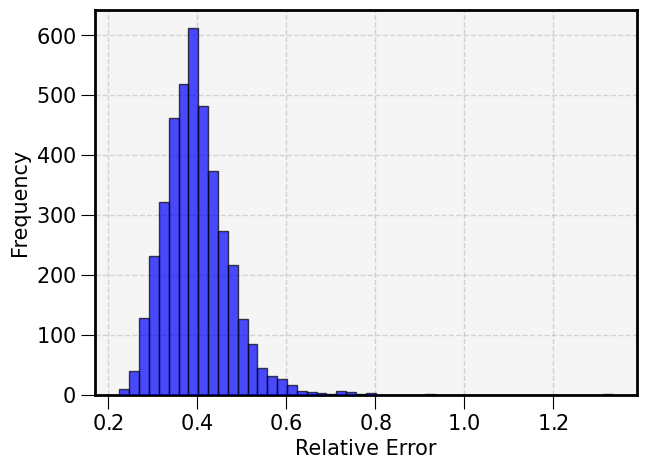

In [11]:
# List of corresponding relative errors
Error_rel = np.array(LSC_REPORT['Rn_Err']) / np.array(LSC_REPORT['Rn_CV'])

# -Plotting
plt.figure(figsize=(7, 5))
plt.hist(Error_rel, bins=50, color='blue', alpha=0.7, edgecolor='black', lw=1.0, zorder=3)
plt.xlabel('Relative Error')
plt.ylabel('Frequency')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

## Representative Points

Let's plot all the LSC data and obtain a representative value per run.

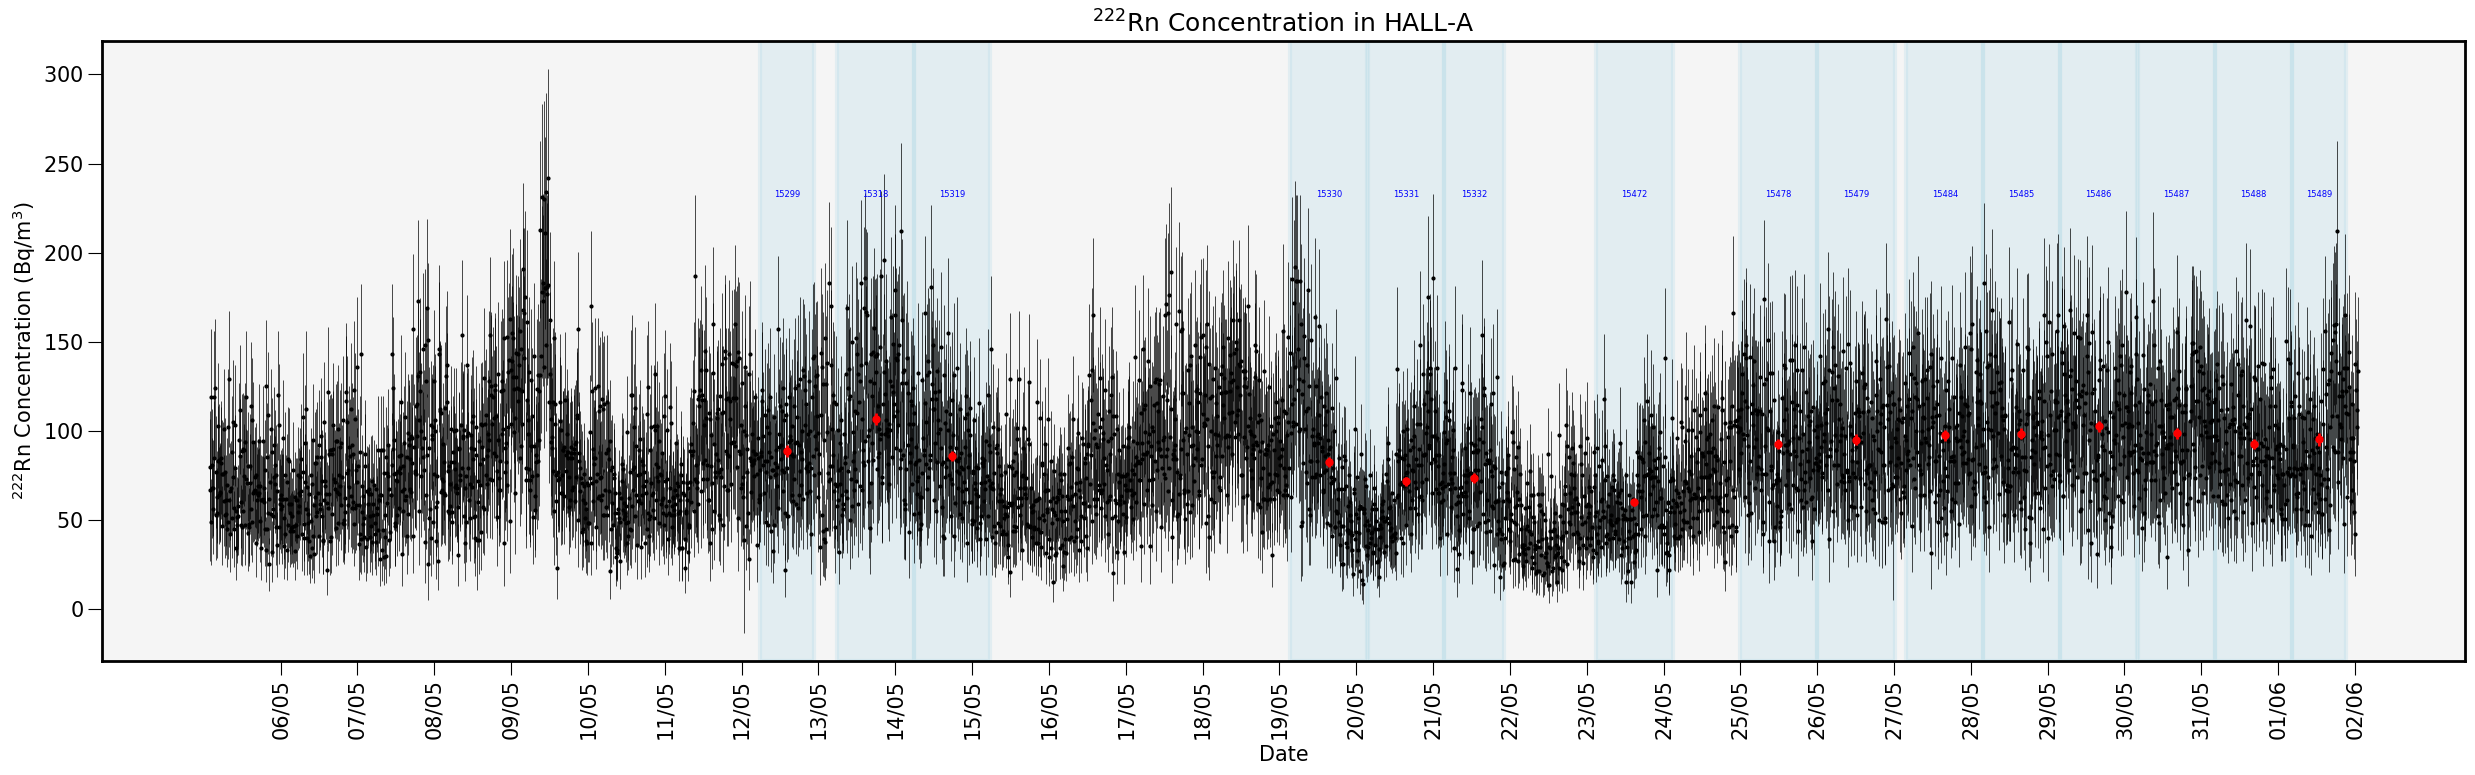

In [12]:
# Global
Date_LSC_CV  = []
Date_LSC_Err = []
Rn_LSC_CV    = []
Rn_LSC_Err   = []

plt.figure(figsize=(25, 8))

# ----- Runs Loop ----- #
for run_id in FIDUCIAL_INFO.keys():

    # Run information
    run_start = FIDUCIAL_INFO[run_id]['start']
    run_end   = FIDUCIAL_INFO[run_id]['end']
    
    # Plot the run period as a shaded area
    plt.axvspan(run_start, run_end, color='lightblue', alpha=0.25)
    plt.text((run_start + run_end) / 2, 230, str(run_id), 
             ha='center', va='bottom', fontsize=6, color='blue')
    
    # ----- Compute a CV for Rn Concentration ----- #
    # Find the closest value of LSC_REPORT['Date'] to run_start and run_end
    start_closest = min(LSC_REPORT['Date'], key=lambda x: abs(x - run_start))
    end_closest   = min(LSC_REPORT['Date'], key=lambda x: abs(x - run_end))
    date_indices  = [i for i, t in enumerate(LSC_REPORT['Date']) if start_closest <= t <= end_closest]

    # Mean date + error per run
    x_values = [LSC_REPORT['Date'][i] for i in date_indices]
    Date_LSC_CV.append(np.mean(x_values))
    Date_LSC_Err.append(np.std(x_values) / np.sqrt(len(x_values)))

    # Weighted mean and error for Rn Concentration per run
    y_values = [LSC_REPORT['Rn_CV'][i] for i in date_indices]
    y_vars   = [LSC_REPORT['Rn_Err'][i]**2 for i in date_indices] 
    weights = [1 / var for var in y_vars]
    y_CV  = np.average(y_values, weights=None)
    y_err = np.sqrt(np.sum(y_vars)) / len(y_values)

    Rn_LSC_CV.append(y_CV)
    Rn_LSC_Err.append(y_err)

# ----- Plotting ----- #
# LSC data
plt.errorbar(LSC_REPORT['Date'], LSC_REPORT['Rn_CV'], yerr=LSC_REPORT['Rn_Err'], fmt='o', ms=2, c='black', ecolor='black', elinewidth=0.5)
# Run data
plt.errorbar(Date_LSC_CV, Rn_LSC_CV, xerr=Date_LSC_Err, yerr=Rn_LSC_Err, fmt='o', ms=5, c='red', ecolor='red', zorder=3)

# ----- Styling ----- #
plt.xlabel('Date')
plt.ylabel(r'$^{222}$Rn Concentration (Bq/m$^3$)')
plt.title(r'$^{222}$Rn Concentration in HALL-A')

# Filter xticks to show only one per day at 12:00:00
dates_human = [crudo.epoch_converter(t, h=True) for t in LSC_REPORT['Date']]        #  Convert epoch time to human-readable format
# If they are just '12:00', check Crudo
noon_ticks  = [LSC_REPORT['Date'][i] for i in range(len(LSC_REPORT['Date'])) if dates_human[i].endswith('12:00')]
noon_labels = [dates_human[i].split(' - ')[0] for i in range(len(dates_human)) if dates_human[i].endswith('12:00')]
plt.xticks(ticks=noon_ticks, labels=noon_labels, rotation=90)

plt.gca().set_facecolor("whitesmoke")
plt.tight_layout()
plt.show()

# Correlation

## RAS: Off

Fit results:
  m = 0.013272 ± 0.005167
  b = (3.26 ± 0.47) mHz
χ² / ndof = 14.82 / 13.00 = 1.14
p-value = 0.32


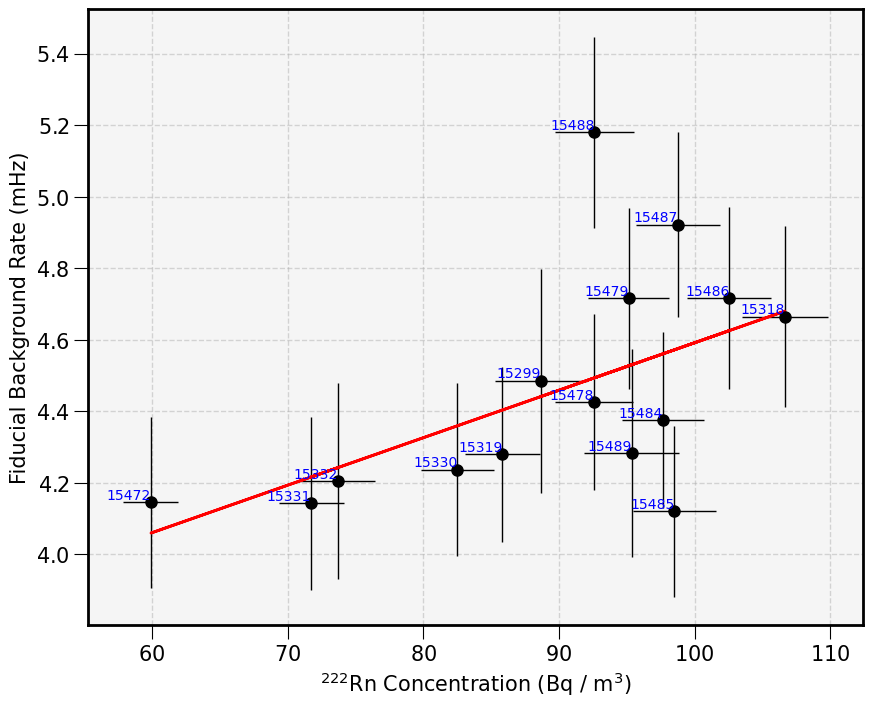

In [13]:
# ----- Linear Fit ----- #
# Preliminary
x_data   = np.array(Rn_LSC_CV)
x_errors = np.array(Rn_LSC_Err)
y_data   = np.array([FIDUCIAL_INFO[run_id]['rate_CV']*1e3  for run_id in FIDUCIAL_INFO.keys()])
y_errors = np.array([FIDUCIAL_INFO[run_id]['rate_Err']*1e3 for run_id in FIDUCIAL_INFO.keys()])

# Define the cost function
least_squares = LeastSquares(x_data, y_data, y_errors, ff.linear_func)

# Define the Minuit object with inital guesses for the parameters
m = Minuit(least_squares, m=10, b=0)

# Minimization process of the cost function and error estimation
m.migrad()
m.hesse()

# Reduced chi-square
chi2 = m.fval
ndof = len(x_data) - m.nfit
p_value = scipy.stats.chi2.sf(chi2, ndof)

print (f"Fit results:\n"
       f"  m = {m.values['m']:.6f} ± {m.errors['m']:.6f}\n"
       f"  b = ({m.values['b']:.2f} ± {m.errors['b']:.2f}) mHz\n"
       f"χ² / ndof = {chi2:.2f} / {ndof:.2f} = {chi2 / ndof:.2f}\n"
       f"p-value = {p_value:.2f}")

# ----- Plotting ----- #
fig, ax = plt.subplots()
# Data
plt.errorbar(x_data, y_data, xerr=x_errors, yerr=y_errors, fmt='o', color='black', ecolor='black', lw=1.0, label='Data')
for x, y, run_id in zip(x_data, y_data, FIDUCIAL_INFO.keys()):
    plt.text(x, y, str(run_id), fontsize=10, ha='right', va='bottom', color='blue')

# Fit
y_fit = ff.linear_func(x_data, m.values['m'], m.values['b'])
plt.plot(x_data, y_fit, color='red', ls='-', label=f"Linear fit\nb = ({m.values['b']:.2f} ± {m.errors['b']:.2f}) mHz\nχ² / ndof = {chi2 / ndof:.2f}")

# ----- Styling ----- #
# Important text
# plt.text(115.5, 5.5, f'intercept R = ({m.values["b"]:.2f} ± {m.errors["b"]:.2f}) mHz', va='bottom', ha='right')  # RAS = off (57.5, 5.45)

# # Preliminary logo
# LOGO_BOX  = OffsetImage(PRELIM_LOGO, zoom = 0.1)
# xy = (108, 4.9)       # RAS = off (65, 5.6)
# ab = AnnotationBbox(LOGO_BOX, xy, xybox=(0, 0), xycoords='data', boxcoords="offset points",  frameon=False)
# ax.add_artist(ab)

plt.ylabel('Fiducial Background Rate (mHz)')
plt.xlabel(r'$^{222}$Rn Concentration (Bq / m$^3$)')
# plt.ylim(2.4, 5)        # RAS = off (3.25, 5.75)
# plt.legend()

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/RAS_On_Corr.pdf')
plt.show()

## RAS: On

Fit results:
  b = (3.63 ± 0.05) mHz
χ² / ndof = 22.99 / 24.00 = 0.96
p-value = 0.52


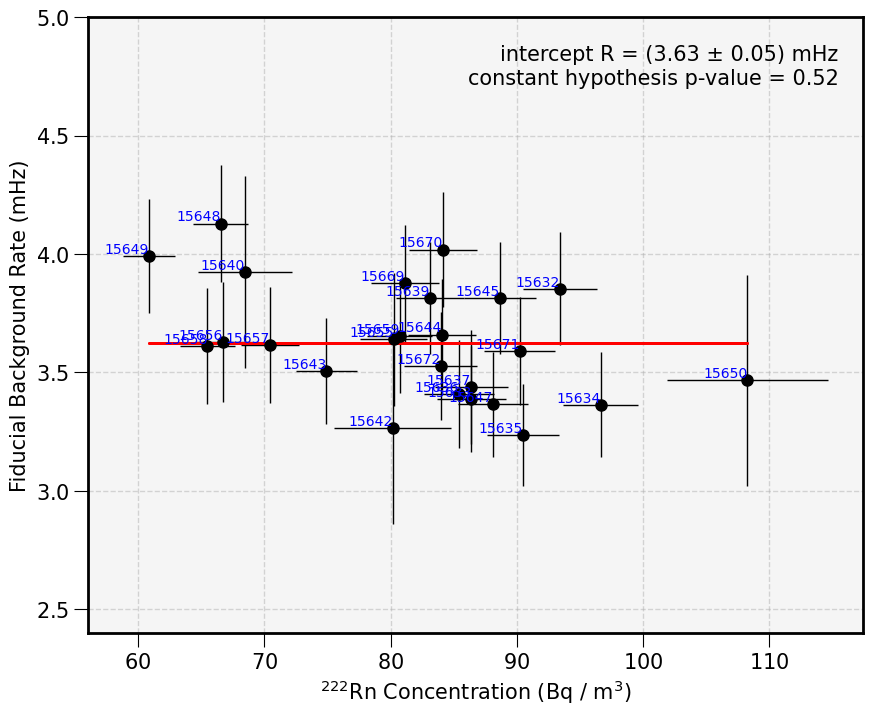

In [15]:
def const_func(x, b):
    return ff.linear_func(x, 0, b)

# ----- Linear Fit ----- #
# Preliminary
x_data   = np.array(Rn_LSC_CV)
x_errors = np.array(Rn_LSC_Err)
y_data   = np.array([FIDUCIAL_INFO[run_id]['rate_CV']*1e3  for run_id in FIDUCIAL_INFO.keys()])
y_errors = np.array([FIDUCIAL_INFO[run_id]['rate_Err']*1e3 for run_id in FIDUCIAL_INFO.keys()])

# Define the cost function
least_squares = LeastSquares(x_data, y_data, y_errors, const_func)

# Define the Minuit object with inital guesses for the parameters
m = Minuit(least_squares, b=0)

# Minimization process of the cost function and error estimation
m.migrad()
m.hesse()

# Reduced chi-square
chi2 = m.fval
ndof = len(x_data) - m.nfit
p_value = scipy.stats.chi2.sf(chi2, ndof)

print (f"Fit results:\n"
       f"  b = ({m.values['b']:.2f} ± {m.errors['b']:.2f}) mHz\n"
       f"χ² / ndof = {chi2:.2f} / {ndof:.2f} = {chi2 / ndof:.2f}\n"
       f"p-value = {p_value:.2f}")

# ----- Plotting ----- #
fig, ax = plt.subplots()
# Data
plt.errorbar(x_data, y_data, xerr=x_errors, yerr=y_errors, fmt='o', color='black', ecolor='black', lw=1.0, label='Data')
for x, y, run_id in zip(x_data, y_data, FIDUCIAL_INFO.keys()):
    plt.text(x, y, str(run_id), fontsize=10, ha='right', va='bottom', color='blue')

# Fit
y_fit = const_func(x_data, m.values['b'])
plt.plot(x_data, y_fit, color='red', ls='-', label=f"Linear fit\nb = ({m.values['b']:.2f} ± {m.errors['b']:.2f}) mHz\nχ² / ndof = {chi2 / ndof:.2f}")

# ----- Styling ----- #
# Important text
plt.text(115.5, 4.8, f'intercept R = ({m.values["b"]:.2f} ± {m.errors["b"]:.2f}) mHz', va='bottom', ha='right')  # RAS = off (57.5, 5.45)
plt.text(115.5, 4.7, f'constant hypothesis p-value = {p_value:.2f}', va='bottom', ha='right')

# # Preliminary logo
# LOGO_BOX  = OffsetImage(PRELIM_LOGO, zoom = 0.1)
# xy = (108, 4.9)       # RAS = off (65, 5.6)
# ab = AnnotationBbox(LOGO_BOX, xy, xybox=(0, 0), xycoords='data', boxcoords="offset points",  frameon=False)
# ax.add_artist(ab)

plt.ylabel('Fiducial Background Rate (mHz)')
plt.xlabel(r'$^{222}$Rn Concentration (Bq / m$^3$)')
plt.ylim(2.4, 5)        # RAS = off (3.25, 5.75)
# plt.legend()

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/RAS_On_Corr.pdf')
plt.show()